## 1. Project Introduction

This project aims to build a machine learning solution to help identify **pneumonia** from clinical data, specifically chest X-ray images.
The main objective is to support faster and more consistent screening, so healthcare professionals can prioritize patients who may need urgent care.

**Pneumonia** is an infection that inflames the air sacs in one or both lungs. These air sacs may fill with fluid or pus, causing symptoms like cough, fever, chest pain, and difficulty breathing. It can be mild or severe, especially for children, older adults, and people with weaker immune systems.

In this context, **machine learning** will learn patterns from labeled medical data and predict whether a new case is showing signs of pneumonia. The model is intended to assist decision-making, not replace doctors, by providing an additional data-driven signal during diagnosis.

## 2. Dataset Loading and Exploration

### 2.1 Imports

In [9]:
import os
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

sns.set_style("whitegrid")

### 2.2 Define Dataset Paths 

In [10]:
DATASET_PATH = Path("../datasets/chest_xray")

train_path = DATASET_PATH / "train"
validation_path = DATASET_PATH / "val"
test_path = DATASET_PATH / "test"

print(f"Train path: {train_path}")
print(f"Validation path: {validation_path}")
print(f"Test path: {test_path}")

Train path: ../datasets/chest_xray/train
Validation path: ../datasets/chest_xray/val
Test path: ../datasets/chest_xray/test


### 2.3 Count Images per Class

In [11]:
def count_images(folder_path):
    counts = {}
    for category in os.listdir(folder_path):
        category_path = folder_path / category
        if category_path.is_dir():
            counts[category] = len(os.listdir(category_path))
    return counts

train_counts = count_images(train_path)
validation_counts = count_images(validation_path)
test_counts = count_images(test_path)

print("Train distribution:", train_counts)
print("Validation distribution:", validation_counts)
print("Test distribution:", test_counts)

Train distribution: {'PNEUMONIA': 3876, 'NORMAL': 1342}
Validation distribution: {'PNEUMONIA': 9, 'NORMAL': 9}
Test distribution: {'PNEUMONIA': 390, 'NORMAL': 234}


We can observe that the distribution is imbalanced. Also, the validation set is extremely samll, which seems useless for any serious tuning. We will probably have to create our own train/validation split.

### 2.4 Convert to DataFrame

In [13]:
df_distribution = pd.DataFrame({
    "Train": train_counts,
    "Validation": validation_counts,
    "Test": test_counts
}).T

df_distribution

,PNEUMONIA,NORMAL
Train,3876,1342
Validation,9,9
Test,390,234


### 2.5 Visualize Class Distribution

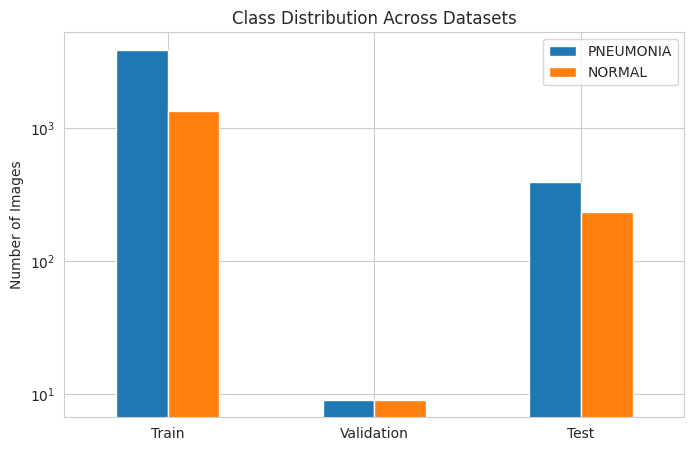

In [16]:
df_distribution.plot(kind="bar", figsize=(8,5))
plt.title("Class Distribution Across Datasets")
plt.ylabel("Number of Images")
plt.yscale("log")
plt.xticks(rotation=0)
plt.show()

### 2.6 Inspect One Image

Image size: (1982, 1603)
Image mode: L


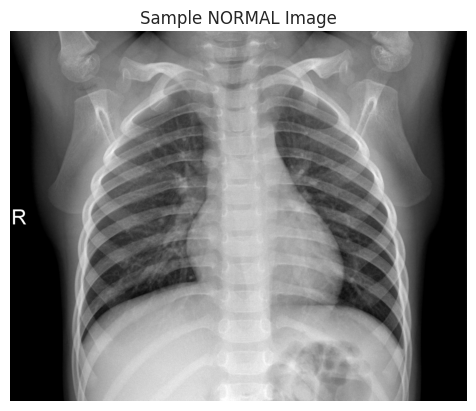

In [17]:
sample_image_path = next((train_path / "NORMAL").glob("*"))
image = Image.open(sample_image_path)

print("Image size:", image.size)
print("Image mode:", image.mode)

plt.imshow(image, cmap="gray")
plt.title("Sample NORMAL Image")
plt.axis("off")
plt.show()

### 2.7 Show Multiple Images per Class

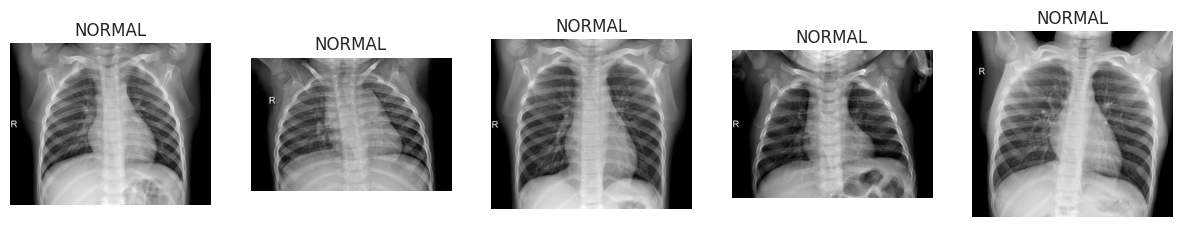

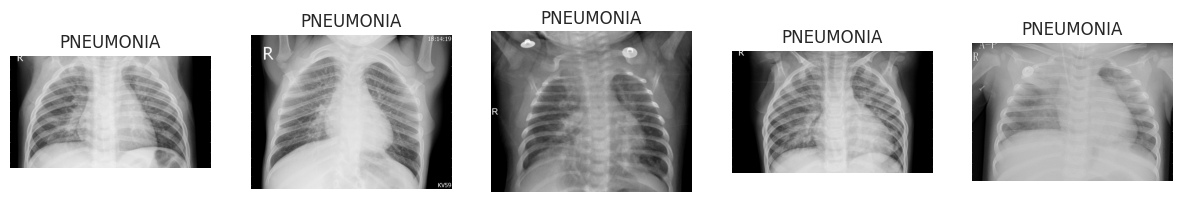

In [ ]:
def show_samples(folder, category, n=5):
    images = list((folder / category).glob("*"))[:n]

    plt.figure(figsize=(15,3))
    for i, img_path in enumerate(images):
        img = Image.open(img_path)
        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap="gray")
        plt.title(category)
        plt.axis("off")
    plt.show()

show_samples(train_path, "NORMAL")
show_samples(train_path, "PNEUMONIA")

Images are not the same size, but machine learning require all inputs to have the same shape. We will have to resize all images to a fixed size.